# E.coli Model Data Generation

 This section covers the initial stages of Generation of the dataset, from loading raw data to engineering features and building dataset for training AI models.

## Required Libraries

This part includes the necessary Python libraries for data processing, machine learning, and visualization. 

In [1]:
# required libraries
import os
import math
import time
from pathlib import Path
import tempfile
import functools
import pandas as pd
import numpy as np
import statistics
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
pd.set_option("display.max_rows", None)
import scipy, joblib
from scipy import stats
from scipy.stats import pearsonr
from scipy.optimize import curve_fit
import sklearn
import xgboost as xg
from matplotlib.pyplot import figure
from matplotlib import pyplot
from IPython.display import display, clear_output
import logging
from meteostat import Point, Daily, Hourly
from datetime import datetime, timedelta
import urllib
from urllib.error import HTTPError
import pickle
import requests
import folium
from folium.plugins import HeatMap, Draw, HeatMapWithTime
from tqdm.contrib.concurrent import process_map
import uuid
import pyarrow as pa
import pyarrow.parquet as pq
from utils import convert_date_to_ayyyyddd, meters_to_lat
import warnings
warnings.filterwarnings('ignore')

In [130]:
cache_dir = "data"
cache_dir = Path(tempfile.gettempdir()) if cache_dir is None else Path(cache_dir)
cache_dir = cache_dir 
        
# make cache dir
cache_dir.mkdir(exist_ok=True, parents=True)

## Validation Data Extraction

This step involves reading and loading the raw validation dataset, typically from CSV, Excel, JSON, RDF or a database. It also includes an initial inspection of the data (e.g., checking for missing values, data types, and summary statistics).

Here we load EA water quality archive from our repo. Data is loaded and cocatenated from July 2024 til July 2025.

[This is the link to source repo.](https://environment.data.gov.uk/water-quality/view/download/new)

In [131]:
# Loading WQ_EA Data
path = "gs://rdmai_dev_data/raw/Water_Quality_EA/2024_all.csv"
path2 = "gs://rdmai_dev_data/raw/Water_Quality_EA/2025.csv"
dataset = pd.read_csv(path, sep=",")
dataset = pd.concat([dataset, pd.read_csv(path2, sep=",")]).reset_index(drop=True)

dataset.shape

(2827512, 17)

In [132]:
dataset.head()

,@id,sample.samplingPoint,sample.samplingPoint.notation,sample.samplingPoint.label,sample.sampleDateTime,determinand.label,determinand.definition,determinand.notation,resultQualifier.notation,result,codedResultInterpretation.interpretation,determinand.unit.label,sample.sampledMaterialType.label,sample.isComplianceSample,sample.purpose.label,sample.samplingPoint.easting,sample.samplingPoint.northing
0,http://environment.data.gov.uk/water-quality/d...,http://environment.data.gov.uk/water-quality/i...,AN-011471,BUCKINGHAM GARDEN CENTRE,2024-10-22T12:44:00,Site Inspect,Site Inspection : Pass/Fail (1/0),4883,NaN,1.0,NaN,coded,FINAL SEWAGE EFFLUENT,True,COMPLIANCE AUDIT (PERMIT),467600,233410
1,http://environment.data.gov.uk/water-quality/d...,http://environment.data.gov.uk/water-quality/i...,AN-011638,"AKELEY WOOD SENIOR SCHOOL, AKELEY WOOD",2024-03-01T11:13:00,NO FLOW/SAMP,No flow /No sample,7668,NaN,0.0,NaN,coded,FINAL SEWAGE EFFLUENT,True,COMPLIANCE AUDIT (PERMIT),468847,237506
2,http://environment.data.gov.uk/water-quality/d...,http://environment.data.gov.uk/water-quality/i...,AN-011638,"AKELEY WOOD SENIOR SCHOOL, AKELEY WOOD",2024-06-21T11:56:00,NO FLOW/SAMP,No flow /No sample,7668,NaN,0.0,NaN,coded,FINAL SEWAGE EFFLUENT,True,COMPLIANCE AUDIT (PERMIT),468847,237506
3,http://environment.data.gov.uk/water-quality/d...,http://environment.data.gov.uk/water-quality/i...,AN-011638,"AKELEY WOOD SENIOR SCHOOL, AKELEY WOOD",2024-09-13T10:00:00,NO FLOW/SAMP,No flow /No sample,7668,NaN,0.0,NaN,coded,FINAL SEWAGE EFFLUENT,True,COMPLIANCE AUDIT (PERMIT),468847,237506
4,http://environment.data.gov.uk/water-quality/d...,http://environment.data.gov.uk/water-quality/i...,AN-011638,"AKELEY WOOD SENIOR SCHOOL, AKELEY WOOD",2024-12-05T11:17:00,NO FLOW/SAMP,No flow /No sample,7668,NaN,0.0,NaN,coded,FINAL SEWAGE EFFLUENT,True,COMPLIANCE AUDIT (PERMIT),468847,237506


### Droping unnecessary columns

In [133]:
# drop unnecessary columns
datasetx = dataset.drop(['@id','codedResultInterpretation.interpretation'],axis=1)
datasetx = datasetx.drop(['sample.samplingPoint.label','determinand.definition','determinand.notation','resultQualifier.notation','determinand.unit.label','sample.isComplianceSample','sample.purpose.label'],axis=1)
datasetx.head()

,sample.samplingPoint,sample.samplingPoint.notation,sample.sampleDateTime,determinand.label,result,sample.sampledMaterialType.label,sample.samplingPoint.easting,sample.samplingPoint.northing
0,http://environment.data.gov.uk/water-quality/i...,AN-011471,2024-10-22T12:44:00,Site Inspect,1.0,FINAL SEWAGE EFFLUENT,467600,233410
1,http://environment.data.gov.uk/water-quality/i...,AN-011638,2024-03-01T11:13:00,NO FLOW/SAMP,0.0,FINAL SEWAGE EFFLUENT,468847,237506
2,http://environment.data.gov.uk/water-quality/i...,AN-011638,2024-06-21T11:56:00,NO FLOW/SAMP,0.0,FINAL SEWAGE EFFLUENT,468847,237506
3,http://environment.data.gov.uk/water-quality/i...,AN-011638,2024-09-13T10:00:00,NO FLOW/SAMP,0.0,FINAL SEWAGE EFFLUENT,468847,237506
4,http://environment.data.gov.uk/water-quality/i...,AN-011638,2024-12-05T11:17:00,NO FLOW/SAMP,0.0,FINAL SEWAGE EFFLUENT,468847,237506


### Seperate time and date columns and keeping only samples of interest

In [134]:
# seperate time and date columns and keeping only samples of interest
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings('ignore')

# Ensure datasetx exists and is a DataFrame
if 'datasetx' not in locals() or not isinstance(datasetx, pd.DataFrame):
    raise ValueError("datasetx is not defined or not a DataFrame")

# Separate time and date columns with error handling
try:
    datasetx['timedate'] = datasetx['sample.sampleDateTime'].str.replace('T',' ')
    datasetx['date'] = pd.to_datetime(datasetx['timedate'],format='%Y-%m-%d %H:%M:%S').dt.date
    datasetx['time'] = pd.to_datetime(datasetx['timedate'],format='%Y-%m-%d %H:%M:%S').dt.time
except Exception as e:
    logging.error(f"Error processing date/time columns: {e}")
    raise
    
# Ensure required columns exist before renaming
required_columns = ['determinand.label', 'sample.samplingPoint.notation']
for col in required_columns:
    if col not in datasetx.columns:
        raise KeyError(f"Missing required column: {col}")

datasetx.rename(columns = {'determinand.label':'determinandlabel'}, inplace = True)
datasetx.rename(columns = {'sample.samplingPoint.notation':'samplingPointnotation'}, inplace = True)

logging.info(f"Dataset shape after processing: {datasetx.shape}")

# Finding locations containing E. coli with error handling
try:
    counts = datasetx.groupby(['samplingPointnotation', 'determinandlabel']).size().to_frame(name='counts').reset_index()#.agg(['count', mean])
    counts = counts.loc[counts['determinandlabel'].str.contains("coli")].sort_values(by=['counts'], ascending=False).reset_index(drop=True)
    counts = counts.drop_duplicates(subset=['samplingPointnotation']).reset_index(drop=True)
    samplingPointnotation = counts.samplingPointnotation.unique()

    datasetx = datasetx.loc[datasetx['samplingPointnotation'].isin(samplingPointnotation)]
    timedate = datasetx.loc[datasetx['determinandlabel'].str.contains("coli")].timedate.unique()
    datasetx = datasetx.loc[datasetx['timedate'].isin(timedate)]
except Exception as e:
    logging.error(f"Error filtering E. coli locations: {e}")
    raise

logging.info(f"Dataset shape after filtering: {datasetx.shape}")
datasetx.head()

2025-07-17 13:33:23,623 - INFO - Dataset shape after processing: (2827512, 11)
2025-07-17 13:33:24,373 - INFO - Dataset shape after filtering: (257010, 11)


,sample.samplingPoint,samplingPointnotation,sample.sampleDateTime,determinandlabel,result,sample.sampledMaterialType.label,sample.samplingPoint.easting,sample.samplingPoint.northing,timedate,date,time
10543,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-04-10T08:18:00,Vol Filtered,520.0,RIVER / RUNNING SURFACE WATER,528150,271970,2024-04-10 08:18:00,2024-04-10,08:18:00
10544,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-04-10T08:18:00,IE Pres,270.0,RIVER / RUNNING SURFACE WATER,528150,271970,2024-04-10 08:18:00,2024-04-10,08:18:00
10545,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-04-10T08:18:00,IE Conf,160.0,RIVER / RUNNING SURFACE WATER,528150,271970,2024-04-10 08:18:00,2024-04-10,08:18:00
10546,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-04-10T08:18:00,MST Filter,2.0,RIVER / RUNNING SURFACE WATER,528150,271970,2024-04-10 08:18:00,2024-04-10,08:18:00
10547,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-04-10T08:18:00,E.coli C-MF,1200.0,RIVER / RUNNING SURFACE WATER,528150,271970,2024-04-10 08:18:00,2024-04-10,08:18:00


### Save all raw E.coli samples

In [17]:
# Save all raw E.coli samples
#datasetx.to_csv('data/val_ecoli_raw_all_git.csv', index=False)
datasetx = pd.read_csv('data/val_ecoli_raw_all_git.csv') 
datasetx.timedate.unique().shape  

(18083,)

## Data Engineering

Data engineering includes transforming raw data into a more useful structure. 

### Rename some columns

In [3]:
datasetx.rename(columns = {'sample.samplingPoint.notation':'samplingPointnotation'}, inplace = True)
datasetx.rename(columns = {'sample.samplingPoint.easting':'easting'}, inplace = True)
datasetx.rename(columns = {'sample.samplingPoint.northing':'northing'}, inplace = True)
print(datasetx.shape)

(257010, 11)


### Transpose the dataframe from Horizental to Vertical representation

In [4]:
# Transpose the dataframe from horizental to Vertical representation
import warnings
warnings.filterwarnings('ignore')
try:
    column_list = datasetx.determinandlabel.unique()
    column_list = np.append(['easting','northing','samplesamplingPoint', 'samplingPointnotation', 'timedate', 'date', 'time'], column_list)
    datasetxx = pd.DataFrame(columns=column_list)
except Exception as e:
    logging.error(f"Error initializing datasetxx: {e}")
    raise
j = 0
for timedate in datasetx.timedate.unique():
    j += 1
    if j%1000 == 0:
        print(j)
    class_ = datasetx.loc[datasetx['timedate'] == timedate]
    if class_.loc[class_['determinandlabel'].str.contains("coli")].reset_index(drop=True).shape[0] >= 1: #if there was ecoli in the given timedate
        datasetxx.loc[len(datasetxx)] = pd.Series(dtype='float64') # create empty row

        datasetxx.iloc[[-1],0:7] = [class_['easting'].iloc[0], class_['northing'].iloc[0],
                                    class_['sample.samplingPoint'].iloc[0], class_['samplingPointnotation'].iloc[0]
                                  , class_['timedate'].iloc[0], class_['date'].iloc[0], class_['time'].iloc[0]] # replace NaN with first seven columns
        for label in class_.determinandlabel.unique():
            datasetxx[label].iloc[-1] = class_[class_.determinandlabel == label]['result'].iloc[0] # replace NaN with rest related columns


1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000


### Create (longitude, latitude) columns from (easting, northing)

In [5]:
from pyproj import Proj, transform

v84 = Proj(proj="latlong",towgs84="0,0,0",ellps="WGS84")
v36 = Proj(proj="latlong", k=0.9996012717, ellps="airy",
    towgs84="446.448,-125.157,542.060,0.1502,0.2470,0.8421,-20.4894")
vgrid = Proj(init="world:bng")

def convertLL(row):
    #Returns (longitude, latitude)

    easting = row['easting']
    northing = row['northing']

    vlon36, vlat36 = vgrid(easting, northing, inverse=True)

    converted = transform(v36, v84, vlon36, vlat36)

    row['Long'] = converted[0]
    row['Lat'] = converted[1]

    return row

# change (easting, northing) to (longitude, latitude)
datasetxx = datasetxx.apply(convertLL, axis=1)

In [6]:
datasetxx.head()

,easting,northing,samplesamplingPoint,samplingPointnotation,timedate,date,time,Vol Filtered,IE Pres,IE Conf,...,Cyanide - CN,Sn- Filtered,TitaniumFilt,Be DISS,Co- Filtered,Sb DISS,Ag- Filtered,V - Filtered,Long,Lat
0,528150.0,271970.0,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-04-10 08:18:00,2024-04-10,08:18:00,520.0,270.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120797,52.330862
1,528150.0,271970.0,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-05-01 10:49:00,2024-05-01,10:49:00,490.0,450.0,450.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120797,52.330862
2,528150.0,271970.0,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-10-03 10:00:00,2024-10-03,10:00:00,490.0,480.0,430.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120797,52.330862
3,542930.0,252966.0,http://environment.data.gov.uk/water-quality/i...,AN-29M04,2024-04-11 11:33:00,2024-04-11,11:33:00,1000.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087922,52.156476
4,542930.0,252966.0,http://environment.data.gov.uk/water-quality/i...,AN-29M04,2024-05-31 10:17:00,2024-05-31,10:17:00,880.0,300.0,300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087922,52.156476


In [8]:
# val_ecoli_all1_git.csv is the all Types measurement for UK with some duplicated rows

#datasetxx.to_csv('data/val_ecoli_all1_git.csv', index=False)
datasetxx = pd.read_csv('data/val_ecoli_all1_git.csv')
datasetxx.shape

(18083, 543)

(18083, 42)
                  Columns        NaN
0                 easting   0.000000
1                northing   0.000000
2     samplesamplingPoint   0.000000
3   samplingPointnotation   0.000000
4                timedate   0.000000
5                    date   0.000000
6                    time   0.000000
7            Vol Filtered  34.424598
8                 IE Pres   5.214843
9                 IE Conf  18.586518
10             MST Filter  34.225516
11            E.coli C-MF   0.414754
12             N Oxidised  90.007189
13              Nitrate-N  91.052370
14              Nitrite-N  90.875408
15            O Diss %sat  90.814577
16           Orthophospht  90.090140
17             Temp Water  34.363767
18             Cond @ 25C  92.219211
19            Oxygen Diss  92.683736
20             Ammonia(N)  89.354642
21                     pH  91.704916
22             BWP - A.B.  45.025715
23             BWP - O.L.  45.014655
24             BWP - A.F.  45.020185
25           SewageDebris 

<Axes: title={'center': 'Missing Values (NaN) Percentage Per Feature'}, ylabel='Columns'>

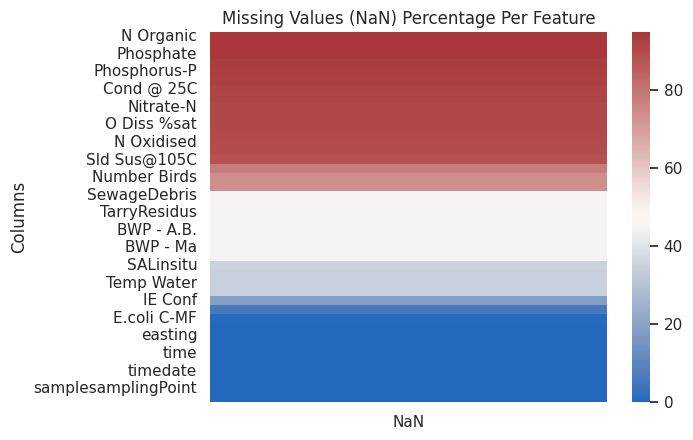

In [14]:
# checking out columns with more than nn% NaN
nn = 95
datasetxxn = datasetxx.drop(datasetxx.loc[:,list((100*(datasetxx.isnull().sum()/len(datasetxx.index))>nn))].columns, axis=1) 
print(datasetxxn.shape)
df = pd.DataFrame({'Columns': datasetxxn.columns, 'NaN': list((100*(datasetxxn.isnull().sum()/len(datasetxxn.index))))})
print(df)
plt.title('Missing Values (NaN) Percentage Per Feature')
df.set_index('Columns', inplace=True)
nans = df.NaN.sort_values(ascending=False).to_frame()
sns.heatmap(nans,cmap='vlag')

<Axes: >

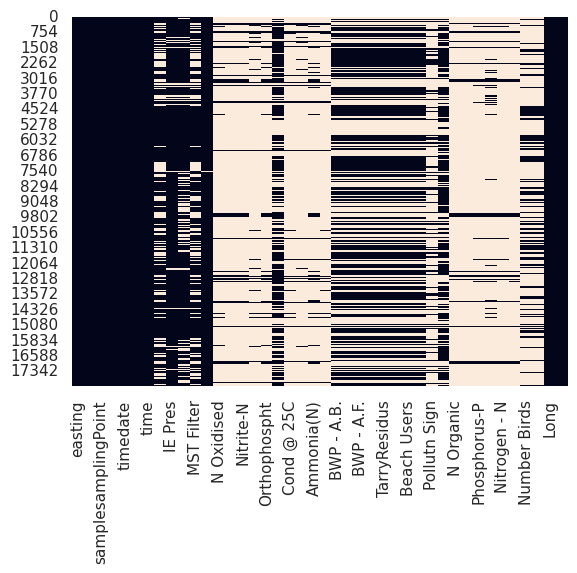

In [15]:
# checking the Nans distribution
miss = datasetxxn.isna()
sns.heatmap(miss,cbar=False)

### Keep features with atleast 5% (n=95) of valid measurements (not NaN)

In [16]:
# keep features with atleast 5% (n=95) of valid measurements (not NaN)
nn = 95
datasetxx = datasetxx.drop(datasetxx.loc[:,list((100*(datasetxx.isnull().sum()/len(datasetxx.index))>nn))].columns, axis=1) 
print(datasetxx.shape)

(18083, 42)


In [17]:
datasetxx.head()

,easting,northing,samplesamplingPoint,samplingPointnotation,timedate,date,time,Vol Filtered,IE Pres,IE Conf,...,N Organic,N-Kjeldahl,Phosphorus-P,Sld Sus@105C,Nitrogen - N,Phosphate,Number Birds,No of dogs,Long,Lat
0,528150.0,271970.0,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-04-10 08:18:00,2024-04-10,08:18:00,520.0,270.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120797,52.330862
1,528150.0,271970.0,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-05-01 10:49:00,2024-05-01,10:49:00,490.0,450.0,450.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120797,52.330862
2,528150.0,271970.0,http://environment.data.gov.uk/water-quality/i...,AN-26M23,2024-10-03 10:00:00,2024-10-03,10:00:00,490.0,480.0,430.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120797,52.330862
3,542930.0,252966.0,http://environment.data.gov.uk/water-quality/i...,AN-29M04,2024-04-11 11:33:00,2024-04-11,11:33:00,1000.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087922,52.156476
4,542930.0,252966.0,http://environment.data.gov.uk/water-quality/i...,AN-29M04,2024-05-31 10:17:00,2024-05-31,10:17:00,880.0,300.0,300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087922,52.156476


### Droping possible duplicated rows

In [18]:
datasetxx = datasetxx.drop_duplicates(subset=['timedate']).reset_index(drop=True)
datasetxx.shape

(18083, 42)

## Correlation Analysis

Correlation analysis on EA WQ archive data helps identify relationships between different variables with E.coli. A heatmap or correlation matrix is used to detect which features are strongly correlated with E. coli presence. This can help in feature selection.

### Correlation heatmap or matrix

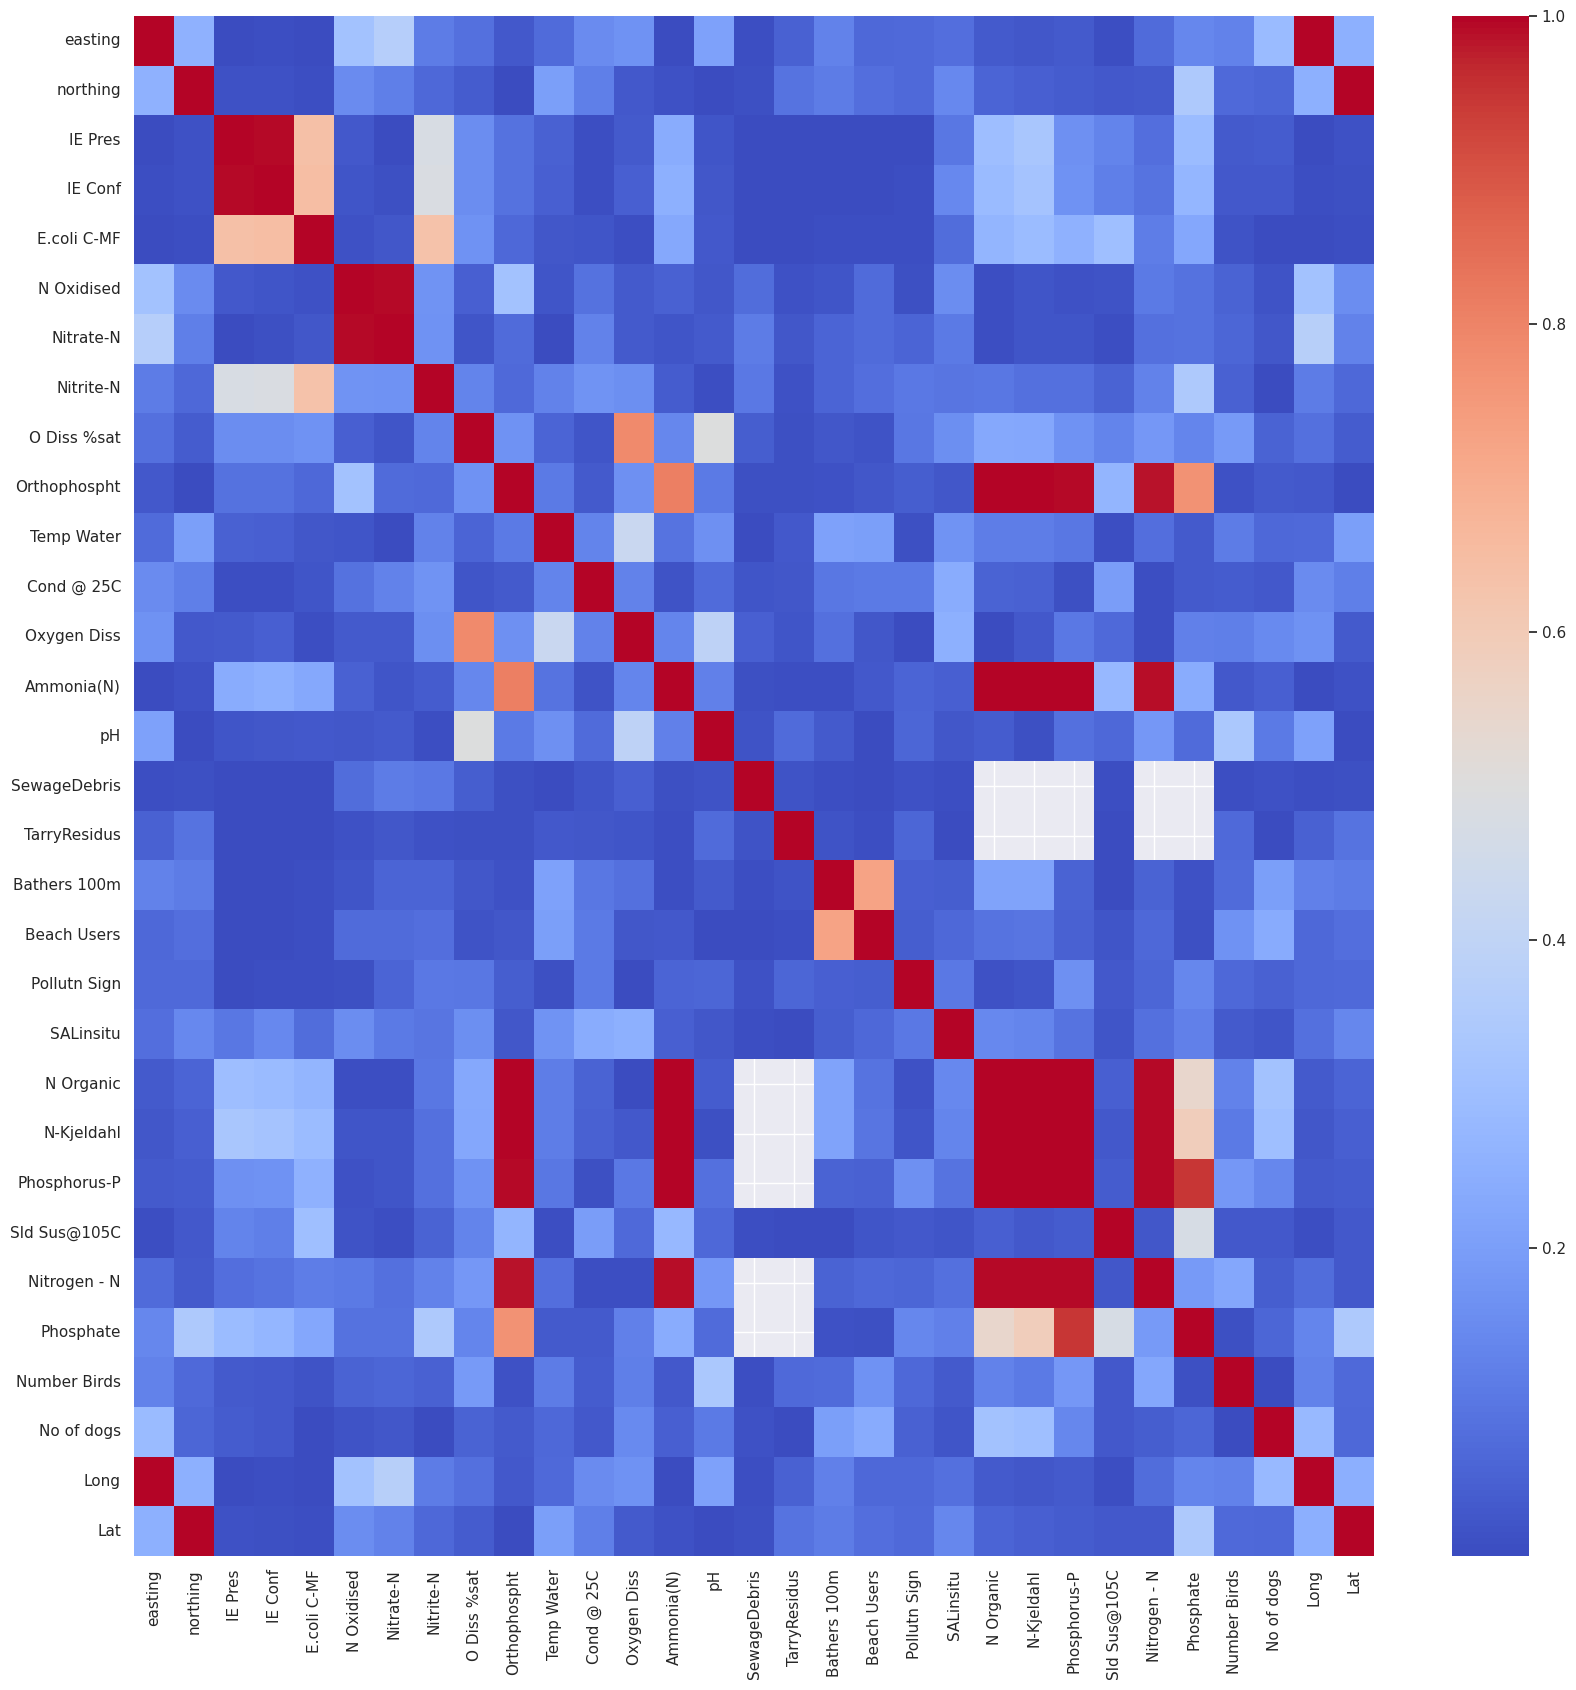

In [20]:
# dropping some irrelevant columns for simplicity in presentation
X = datasetxx.drop(['samplingPointnotation', 'samplesamplingPoint', 'timedate', 'date', 'time',
                   'BWP - A.B.', 'Vol Filtered','BWP - Ma','BWP - O.L.', 'BWP - A.F.','MST Filter'],axis=1)
y = datasetxx['E.coli C-MF']

# correlation analysis
corre = X.corr().abs()
plt.figure(figsize=(20,20))
sns.heatmap(corre,annot=False,cmap="coolwarm")
plt.show()

### Spearman correlation against E.coli

<Axes: xlabel='E.coli C-MF', ylabel='None'>

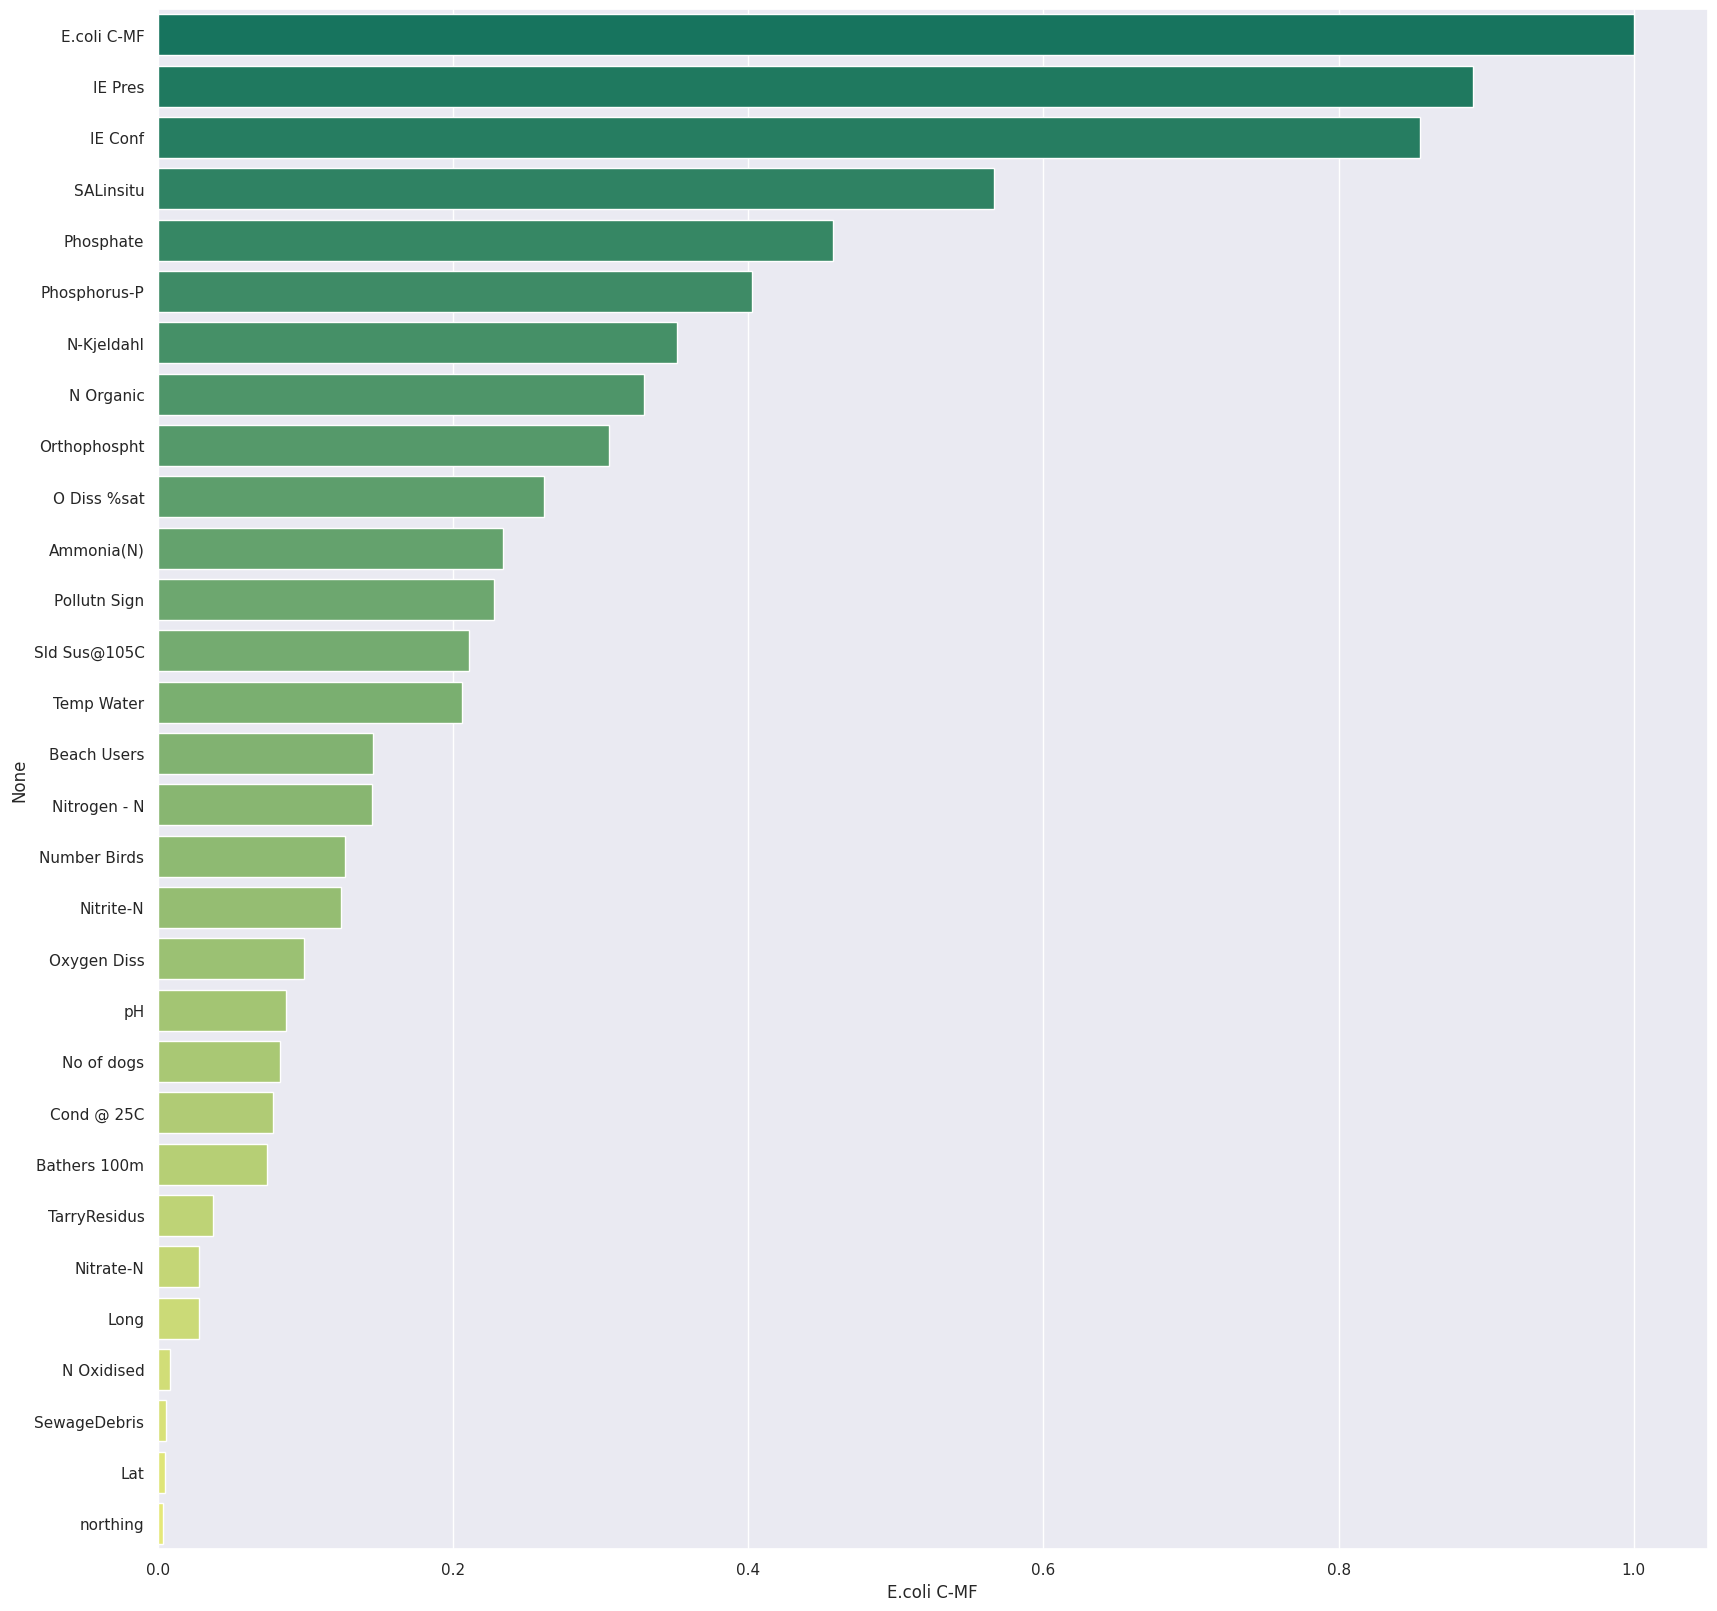

In [21]:
# correlation analysis for E.coli (Sorted)
temp = X.corr(method='spearman')[["E.coli C-MF"]].iloc[1: , :].abs() #kendall
temp = temp.sort_values('E.coli C-MF',ascending=False)
plt.figure(figsize=(20,20))
sns.barplot(x='E.coli C-MF',y=temp.index,data=temp,orient='h',palette='summer')

In [22]:
print(datasetxx.describe())

             easting       northing  Vol Filtered       IE Pres       IE Conf  \
count   18083.000000   18083.000000  11858.000000  1.714000e+04  1.472200e+04   
mean   407510.938561  211982.321407    742.650953  3.732599e+03  3.465413e+03   
std    149184.826165  171202.809071    242.268887  5.765065e+04  5.673419e+04   
min    135560.000000       3.000000      0.000000  1.000000e+00  1.000000e+00   
25%    292620.000000   80058.000000    570.000000  1.000000e+01  1.000000e+01   
50%    398313.000000  140478.000000    820.000000  3.600000e+01  1.800000e+01   
75%    547820.000000  342500.000000    930.000000  3.100000e+02  1.600000e+02   
max    654718.000000  651500.000000   8700.000000  3.900000e+06  3.900000e+06   

         MST Filter   E.coli C-MF   N Oxidised    Nitrate-N    Nitrite-N  ...  \
count  11894.000000  1.800800e+04  1807.000000  1618.000000  1650.000000  ...   
mean       1.999916  1.277375e+04     4.665717     4.108764     0.032285  ...   
std        0.009169  2.3573

### The top 5 most populated sampling locations are listed below.

In [23]:
grouped_data = datasetxx[['E.coli C-MF','Long','Lat']]
grouped_data = grouped_data.dropna().reset_index(drop=True)
grouped_data = grouped_data.groupby(["Lat", "Long"]).agg(
    ecoli_mean = ("E.coli C-MF","mean"),
    ecoli_count = ("E.coli C-MF","count")
).reset_index()
grouped_data.sort_values('ecoli_count',ascending=False).head()

,Lat,Long,ecoli_mean,ecoli_count
2,49.891942,-0.609131,549885.829545,88
270,50.611092,-3.401680,205.779221,77
750,52.188607,1.451225,901.364865,74
272,50.611818,-3.399638,17758.378378,74
754,52.210945,1.267014,1784.273973,73


In [24]:
analysis = datasetxx.describe()

### Plot value counts

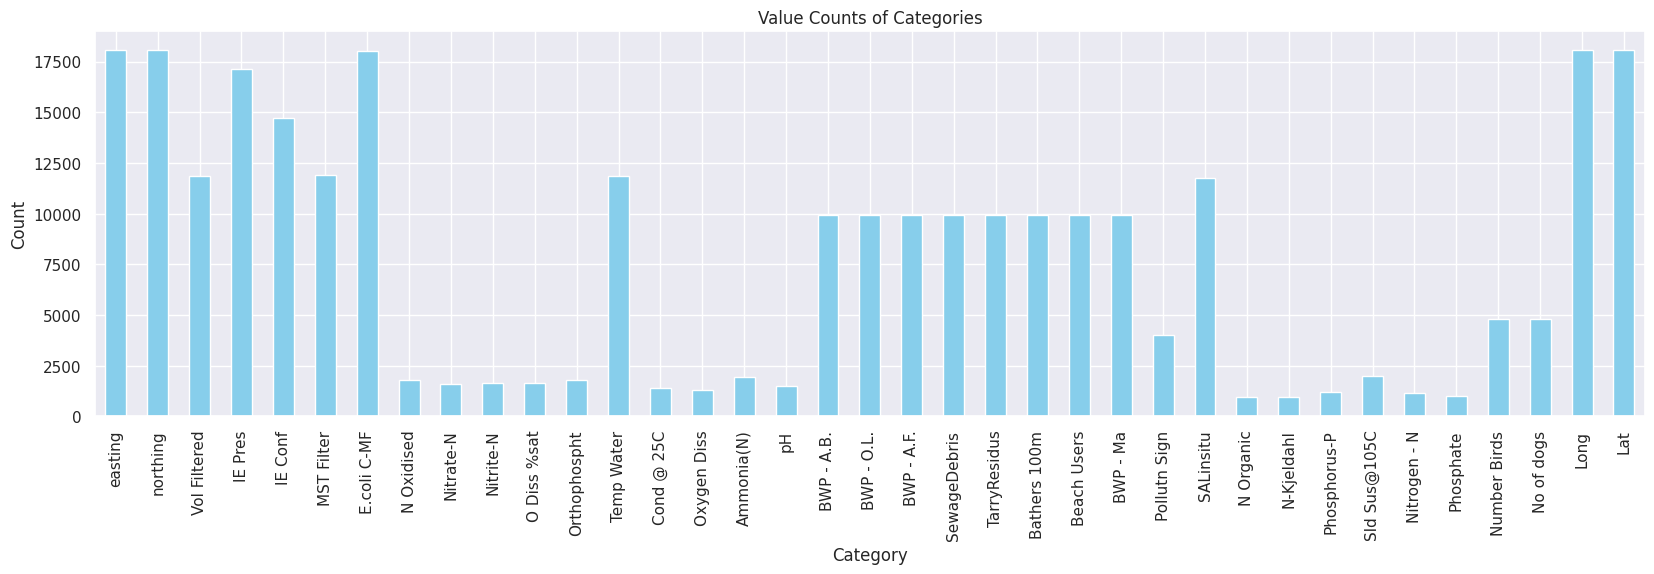

In [25]:
# Plot value counts
plt.figure(figsize=(20,5))
analysis.iloc[0].plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Value Counts of Categories')
plt.show()

### Features distribution box plot

<Axes: >

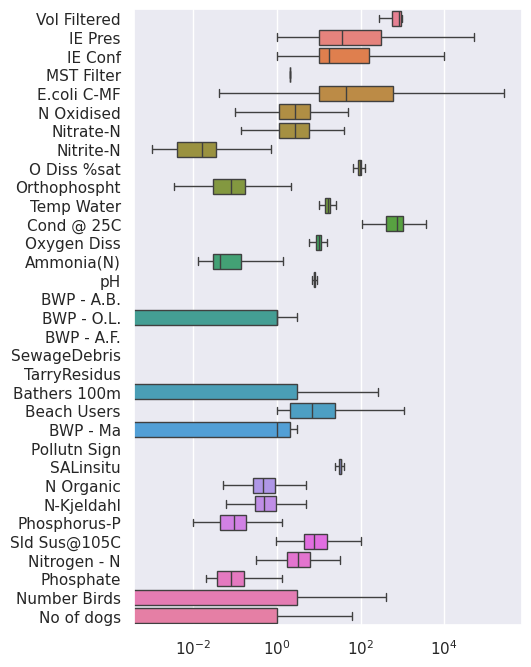

In [31]:
plt.figure(figsize=(5,8))
#plt.xlim(0, 50)
plt.xscale('log')
sns.boxplot(data = datasetxx.drop(['Lat', 'Long', 'easting', 'northing'],axis=1), orient="h", showfliers=False)

In [32]:
datasetxxt = datasetxx.drop_duplicates(subset=['timedate']).reset_index(drop=True)
datasetxxt = datasetxxt[["Temp Water", "Sld Sus@105C", "Ammonia(N)","Nitrate-N","Nitrite-N","Phosphate",
                        "Lat","Long","samplesamplingPoint","samplingPointnotation",
                        "timedate","time","date","E.coli C-MF"]]

datasetxxt = datasetxxt.dropna().reset_index(drop=True)
datasetxxt.head()

,Temp Water,Sld Sus@105C,Ammonia(N),Nitrate-N,Nitrite-N,Phosphate,Lat,Long,samplesamplingPoint,samplingPointnotation,timedate,time,date,E.coli C-MF
0,8.1,52.0,0.030,5.19,0.015,0.220,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,2024-01-03 11:25:00,11:25:00,2024-01-03,1500.0
1,3.8,10.0,0.100,5.08,0.019,0.096,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,2024-01-10 12:29:00,12:29:00,2024-01-10,860.0
2,3.3,8.8,0.120,4.38,0.022,0.066,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,2024-01-17 12:00:00,12:00:00,2024-01-17,310.0
3,7.7,55.0,0.030,6.36,0.037,0.190,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,2024-01-24 12:16:00,12:16:00,2024-01-24,1400.0
4,7.2,8.6,0.091,4.17,0.035,0.062,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,2024-01-31 11:30:00,11:30:00,2024-01-31,220.0


In [33]:
datasetxxt.to_csv('data/val_ecoli_all2_git.csv', index=False)
datasetxx = pd.read_csv('data/val_ecoli_all2_git.csv')
datasetxx.shape

(987, 14)

In [13]:
import IPython
app = IPython.Application.instance() 
app.kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

## Adding Landcover Feature Columns


We use Land cover dataset provides the European continent map describing the land surface into 44 classes, ranging from broad forested areas to individual vineyards. 

The product called CORINE (Coordination of Information on the Environment) program and is updated with new status and change layers every six years—with the most recent update made in 2018.

We use the CORINE map generated from year 2018.

We generated 7 feature from Land cover map, 6 parental categories of "agri","forest","grass","wetland","build","others" and one dominant land cever category "land_cover".

Links to data: https://land.copernicus.eu/en/products/corine-land-cover, https://catalogue.ceh.ac.uk/documents/2fad7f16-6585-438a-9fe3-a7d68ff642f9


In [34]:
# clc2018_uk landcover
import geopandas as gpd
from shapely.geometry import Point, box
import math
import functools
import tarfile
from cloudpathlib import S3Client
from pathlib import Path
from tqdm.contrib.concurrent import process_map
import xarray as xr


def extract_dominant_land_cover(lat, lon, clc_data):

    # Convert the dataframe to a GeoDataFrame
    gdf_points = gpd.GeoDataFrame(
        geometry=[Point(lon, lat)],
        crs="EPSG:4326"  # Assuming WGS84 CRS
    )
    
    # Create 10 km buffers around each point
    km_to_deg = 10 / 110.574  # Convert distance from kilometers to degrees (approx.). 1 degree latitude = 110.574 km
    gdf_points['buffer'] = gdf_points.geometry.buffer(km_to_deg)  # Buffer in degrees 
    buffer = gdf_points['buffer']
    
    # Clip CORINE polygons with the buffer
    clipped = gpd.clip(clc_data, buffer)
    
    # Check if there is any data within the bounding box
    if clipped.empty:
        return None  # No land cover data in the bounding box
    
    # Calculate area for each land cover class within the buffer
    clipped['area'] = clipped.geometry.area
    total_area = clipped['area'].sum()
    clipped['percentage'] = (clipped['area'] / total_area) * 100
    # Store results as a dictionary
    landcover_stats = clipped.groupby('CODE_18')['percentage'].sum().to_dict()
    
    keys_agri = ["211","212","213","221","222","223","241","242","243","244"]
    keys_forest = ["311","312","313"]
    keys_grass = ["321","322","323","324","231"]
    keys_wetland = ["411","412","421","422","423"]
    keys_build = ["111","112","121","122","123","124","131","132","133","141","142"] # Artifical surface
    keys_others = ["331","332","333","334","335"] # sparse and bare area, glacier
        
    agri = sum(landcover_stats.get(key,0) for key in keys_agri)
    agri = sum(landcover_stats.get(key,0) for key in keys_agri)
    forest = sum(landcover_stats.get(key,0) for key in keys_forest)
    grass = sum(landcover_stats.get(key,0) for key in keys_grass)
    wetland = sum(landcover_stats.get(key,0) for key in keys_wetland)
    build = sum(landcover_stats.get(key,0) for key in keys_build)
    others = sum(landcover_stats.get(key,0) for key in keys_others)
    
    # Find the dominant land cover class
    return max(landcover_stats, key=landcover_stats.get), agri,forest,grass,wetland,build,others


shapefile = 'Landcover/clc2018_uk.shp'  # Path to your shapefile
# Load the shapefile (Corine Land Cover data)
clc_data = gpd.read_file(shapefile)
if clc_data.crs != "EPSG:4326":
    clc_data = clc_data.to_crs(epsg=4326)

# Remove water, coastal, sea, and ocean classes
# These CLC codes represent water bodies (44-46)
# (999, 995, 990) represent no data or unclassified
excluded_classes = ["999","990","995","511","512","521","522","523"]
   
# Filter out the unwanted classes
clc_data_filtered = clc_data[~clc_data['CODE_18'].isin(excluded_classes)]

land_covers = process_map(
    functools.partial(extract_dominant_land_cover, clc_data=clc_data_filtered),
    datasetxx.Lat,
    datasetxx.Long,
    chunksize=4,
    max_workers=min(32, os.cpu_count() + 4),
    total=len(datasetxx),)

land_covers = pd.DataFrame(land_covers, columns=["land_cover","agri","forest","grass","wetland","build","others"])
datasetxx = datasetxx.join(land_covers)
datasetxx.to_csv("data/val_ecoliall512_weather.csv", index=False) # df1-12 dataset plus Landcover 44 classes

  0%|          | 0/987 [00:00<?, ?it/s]

### label encoding landcover feature

Only one should be choosed onehot or label encoding. On trained model we used label encoding.

In [38]:
datasetxx = datasetxx.dropna()
datasetxx.shape

(986, 21)

In [39]:
# label encoding landcover data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
classes = [211,212,213,221,222,223,231,241,242,243,244,311,312,313,
            321,322,323,324,411,412,421,422,423,111,112,121,122,123,124,131,132,133,141,142,331,332,333,334,335]
le = LabelEncoder()

le.fit(classes)
datasetxx['land_cover'] = le.transform(datasetxx['land_cover'])
#datasetxx['land_cover'] = le.inverse_transform(datasetxx['land_cover'])
datasetxx.to_csv("data/val_ecoliall512_weather.csv", index=False) # df1-12 dataset plus Landcover 44 classes labelized

### onehot encoding landcover feature

In [85]:
# onehot encoding (only one should be choosed onehot or label encoding). On trained model we used label encoding.
ohe = OneHotEncoder(sparse_output=False)
ohe.fit(np.array(classes).reshape(-1, 1))
lcohe = ohe.transform(np.array(datasetxx['land_cover']).reshape(-1, 1))
#lcohe = pdDataframe(lcohe, columns=[f'land_cover_{int(c)}' for c in ohe.categories_[0]]

In [89]:
lcohe.shape

(21064, 37)

In [40]:
datasetxx = pd.read_csv('data/val_ecoliall512_weather.csv')
datasetxx.shape

(986, 21)

In [41]:
datasetxx.head()

,Temp Water,Sld Sus@105C,Ammonia(N),Nitrate-N,Nitrite-N,Phosphate,Lat,Long,samplesamplingPoint,samplingPointnotation,...,time,date,E.coli C-MF,land_cover,agri,forest,grass,wetland,build,others
0,8.1,52.0,0.030,5.19,0.015,0.220,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,...,11:25:00,2024-01-03,1500.0,11,72.351376,8.718455,12.432385,1.535488,4.962297,0.0
1,3.8,10.0,0.100,5.08,0.019,0.096,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,...,12:29:00,2024-01-10,860.0,11,72.351376,8.718455,12.432385,1.535488,4.962297,0.0
2,3.3,8.8,0.120,4.38,0.022,0.066,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,...,12:00:00,2024-01-17,310.0,11,72.351376,8.718455,12.432385,1.535488,4.962297,0.0
3,7.7,55.0,0.030,6.36,0.037,0.190,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,...,12:16:00,2024-01-24,1400.0,11,72.351376,8.718455,12.432385,1.535488,4.962297,0.0
4,7.2,8.6,0.091,4.17,0.035,0.062,52.188607,1.451225,http://environment.data.gov.uk/water-quality/i...,AN-ALD020,...,11:30:00,2024-01-31,220.0,11,72.351376,8.718455,12.432385,1.535488,4.962297,0.0


## Adding Weather Features Columns

Open-Meteo which is an open-source historical weather API is used to fetch weather data.

The Historical Weather API is based on reanalysis datasets and uses a combination of weather station, aircraft, buoy, radar, and satellite observations to create a comprehensive record of past weather conditions.

19 hourly, 13 daily and 13 weekly weather features are used where the detail can be found in the following table.

These weather data is incorporated, as environmental factors can influence E.coli levels. This step involve merging historical weather data with the existing dataset.

[This is the link to Open-Meteo Historical Weather API Docs.](https://open-meteo.com/en/docs/historical-weather-api)

Commercial clients require Commercial Use License: [For API plans check out here.](https://open-meteo.com/en/pricing)

In [42]:
# Weather data columns from open-meteo API
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry
import time


# Load your water quality dataset
water_quality_df = datasetxx.copy()

# Ensure the 'date' column is in YYYY-MM-DD format
water_quality_df['date'] = pd.to_datetime(water_quality_df['date']).dt.strftime('%Y-%m-%d')

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Function to fetch weather data using the provided Open-Meteo API code
# for free requests remove "customer-" from url and "apikey" from params
def fetch_weather(lat, lon, date):
    url = "https://customer-archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": (datetime.strptime(date, "%Y-%m-%d")  - timedelta(days=7)).strftime("%Y-%m-%d"),
        "end_date": date,
        "hourly": "temperature_2m,relative_humidity_2m,windspeed_10m,windgusts_10m,winddirection_10m,precipitation,rain,snowfall,cloudcover,pressure_msl,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,vapour_pressure_deficit,et0_fao_evapotranspiration,sunshine_duration,global_tilted_irradiance,shortwave_radiation,direct_radiation,dew_point_2m",
        "daily": "temperature_2m_min,temperature_2m_max,precipitation_sum,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,precipitation_hours,sunshine_duration,daylight_duration,shortwave_radiation_sum,et0_fao_evapotranspiration",
        "timezone": "GMT",
        "apikey": "7h5H2w9Qt1vYo2g2"
    }
    
    attempt = 0
    retries = 5
    while attempt < retries:
        try:
            responses = openmeteo.weather_api(url, params=params)
            attempt = retries
        except HTTPError as http_err:
            print(f"Rate limit reached. Retrying in {2 ** attempt} seconds...")
            time.sleep(0.1* 2 ** attempt)  # Exponential backoff
            attempt += 1
        except Exception as e:
            # Handle other potential exceptions (network issues, etc.)
            print(f"Error: {e}")
            print(f"Rate limit reached. Retrying in {2 ** attempt} seconds...")
            time.sleep(0.1* 2 ** attempt)  # Exponential backoff
            attempt += 1

    
    # Process the response for the first location (single request)
    response = responses[0]
    
    # Extract hourly data
    hourly = response.Hourly()
    hourly_data = {
        "temperature_11am": hourly.Variables(0).ValuesAsNumpy()[179], # index = 179 corresponds to the 11 o`clock 
        "humidity_11am": hourly.Variables(1).ValuesAsNumpy()[179],
        "windspeed_11am": hourly.Variables(2).ValuesAsNumpy()[179],
        "windgusts_11am": hourly.Variables(3).ValuesAsNumpy()[179],
        "winddirection_11am": hourly.Variables(4).ValuesAsNumpy()[179],
        "precipitation_11am": hourly.Variables(5).ValuesAsNumpy()[179],
        "rain_11am": hourly.Variables(6).ValuesAsNumpy()[179],
        "snowfall_11am": hourly.Variables(7).ValuesAsNumpy()[179],
        "cloudcover_11am": hourly.Variables(8).ValuesAsNumpy()[179],
        "pressure_msl_11am": hourly.Variables(9).ValuesAsNumpy()[179],
        "soil_temp_7cm": hourly.Variables(10).ValuesAsNumpy()[179],
        "soil_moist_7cm": hourly.Variables(11).ValuesAsNumpy()[179],
        "vap_press_def": hourly.Variables(12).ValuesAsNumpy()[179],
        "et0_fao_evap": hourly.Variables(13).ValuesAsNumpy()[179],
        "sun_duration": hourly.Variables(14).ValuesAsNumpy()[179],
        "global_tilted_irr": hourly.Variables(15).ValuesAsNumpy()[179],
        "short_rad": hourly.Variables(16).ValuesAsNumpy()[179],
        "dir_rad": hourly.Variables(17).ValuesAsNumpy()[179],
        "dew_point_2m": hourly.Variables(18).ValuesAsNumpy()[179]
    }
    
    # Extract daily data
    daily = response.Daily()
    daily_weather = {
        "temp_min": daily.Variables(0).ValuesAsNumpy()[7],  # index = 7 corresponds to the current day 
        "temp_max": daily.Variables(1).ValuesAsNumpy()[7],
        "precipitation_sum": daily.Variables(2).ValuesAsNumpy()[7],
        "rain_sum": daily.Variables(3).ValuesAsNumpy()[7],
        "snowfall_sum": daily.Variables(4).ValuesAsNumpy()[7],
        "windspeed_max": daily.Variables(5).ValuesAsNumpy()[7],
        "windgusts_max": daily.Variables(6).ValuesAsNumpy()[7],
        "winddirection_dominant": daily.Variables(7).ValuesAsNumpy()[7],
        "precipitation_hours": daily.Variables(8).ValuesAsNumpy()[7],
        "sunshine_duration_d": daily.Variables(9).ValuesAsNumpy()[7],
        "daylight_duration_d": daily.Variables(10).ValuesAsNumpy()[7],
        "short_rad_sum_d": daily.Variables(11).ValuesAsNumpy()[7],
        "et0_fao_evap_d": daily.Variables(12).ValuesAsNumpy()[7]
    }
    
    
    # Extract weekly data
    weekly_weather = {
        "temp_min7": daily.Variables(0).ValuesAsNumpy().mean(),
        "temp_max7": daily.Variables(1).ValuesAsNumpy().mean(),
        "precipitation_sum7": daily.Variables(2).ValuesAsNumpy().sum(),
        "rain_sum7": daily.Variables(3).ValuesAsNumpy().sum(),
        "snowfall_sum7": daily.Variables(4).ValuesAsNumpy().sum(),
        "windspeed_max7": daily.Variables(5).ValuesAsNumpy().mean(),
        "windgusts_max7": daily.Variables(6).ValuesAsNumpy().mean(),
        "winddirection_dominant7": daily.Variables(7).ValuesAsNumpy().mean(),
        "precipitation_hours7": daily.Variables(8).ValuesAsNumpy().sum(),
        "sunshine_duration_d7": daily.Variables(9).ValuesAsNumpy().sum(),
        "daylight_duration_d7": daily.Variables(10).ValuesAsNumpy().sum(),
        "short_rad_sum_d7": daily.Variables(11).ValuesAsNumpy().sum(),
        "et0_fao_evap_d7": daily.Variables(12).ValuesAsNumpy().sum()
    }
    return {**hourly_data, **daily_weather, **weekly_weather}


Add new columns to your DataFrame for hourly and daily parameters

In [43]:
# Add new columns to your DataFrame for hourly and daily parameters
hourly_columns = ["temperature_11am", "humidity_11am", "windspeed_11am", "windgusts_11am", 
                    "winddirection_11am", "precipitation_11am", "rain_11am", "snowfall_11am",
                    "cloudcover_11am", "pressure_msl_11am","soil_temp_7cm","soil_moist_7cm","vap_press_def",
                  "et0_fao_evap","sun_duration","global_tilted_irr","short_rad","dir_rad","dew_point_2m"]
daily_columns = ["temp_min", "temp_max", "precipitation_sum", "rain_sum", "snowfall_sum",
                    "windspeed_max", "windgusts_max", "winddirection_dominant",
                    "precipitation_hours", "sunshine_duration_d", "daylight_duration_d", "short_rad_sum_d", "et0_fao_evap_d"]
weekly_columns = ["temp_min7", "temp_max7", "precipitation_sum7", "rain_sum7", "snowfall_sum7",
                    "windspeed_max7", "windgusts_max7", "winddirection_dominant7",
                    "precipitation_hours7", "sunshine_duration_d7", "daylight_duration_d7", "short_rad_sum_d7", "et0_fao_evap_d7"]

program_starts = time.time()
j = 0
for col in hourly_columns + daily_columns + weekly_columns:
    water_quality_df[col] = None

# Iterate over each row in the DataFrame to fetch weather data
for idx, row in water_quality_df.iterrows():
    try:
        weather_data = fetch_weather(row["Lat"], row["Long"], row["date"])
    except:
        
        print("API limit hit.")
        time.sleep(34)  # to cope with API limit
        weather_data = fetch_weather(row["Lat"], row["Long"], row["date"])
        
    if weather_data:
        for col in weather_data.keys():
            water_quality_df.at[idx, col] = weather_data[col]
    
    # Pause to avoid hitting rate limits
    time.sleep(0.01) 
    j = j + 1
    if j%100 == 0:
        now = time.time()
        print("It has been {0} sec and {1} iterations since the loop started".format(now - program_starts, j))
        # Setup the Open-Meteo API client with cache and retry on error
        cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
        retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
        openmeteo = openmeteo_requests.Client(session=retry_session)

# Save the updated DataFrame
water_quality_df.to_csv("data/val_ecoliall51_weather.csv", index=False)
water_quality_df.shape

It has been 9.29786467552185 sec and 100 iterations since the loop started
It has been 15.884708166122437 sec and 200 iterations since the loop started
It has been 25.023192405700684 sec and 300 iterations since the loop started
It has been 31.00703263282776 sec and 400 iterations since the loop started
It has been 38.27510094642639 sec and 500 iterations since the loop started
It has been 44.49671459197998 sec and 600 iterations since the loop started
It has been 51.765974283218384 sec and 700 iterations since the loop started
It has been 59.290810346603394 sec and 800 iterations since the loop started
It has been 66.23788905143738 sec and 900 iterations since the loop started


(986, 66)

In [53]:
water_quality_df.shape

(986, 66)

In [ ]:
# to save the dataframes of water_quality_df if hitting daily API limit under free API for public users
# This parts can be ignored as we used it for training data preperation
df1 = water_quality_df.iloc[:j,:]
df1.to_csv("dfl12.csv", index=False)
print(j)

In [ ]:
# concate the dataframes of water_quality_df after fetching all samples
# This parts can be ignored as we used it for training data preperation
# Respecting API limits (hourly, daily and monthly) can be followed to avoid concating approach
df_merged = pd.concat([df1, df2], ignore_index=True, sort=False)

In [ ]:
datasetxx = pd.read_csv('data/val_ecoliall51_weather.csv')
datasetxx.shape

## MODIS Satellite 

[MODIS](https://modis.gsfc.nasa.gov/data/) (or Moderate Resolution Imaging Spectroradiometer) is a key instrument two satellites with a 500 m spatial resolution. The MODIS instrument is operating on both the Terra and Aqua spacecraft. MODIS satellites are acquiring data in 36 spectral bands. It has a viewing swath width of 2,330 km and views the entire surface of the Earth every one to two days. 

The [MOD15A2H](https://lpdaac.usgs.gov/products/mod15a2hv061/) Version 6.1 Moderate Resolution Imaging Spectroradiometer (MODIS) combined Leaf Area Index (LAI) and Fraction of Photosynthetically Active Radiation (FPAR) product is an 8-day composite dataset with 500 meter (m) pixel size. The algorithm chooses the “best” pixel available from all the acquisitions of the Terra sensor from within the 8-day period.
LAI is defined as the one-sided green leaf area per unit ground area in broadleaf canopies and as one-half the total needle surface area per unit ground area in coniferous canopies. FPAR is defined as the fraction of incident photosynthetically active radiation, 400-700 nanometers (nm), absorbed by the green elements of a vegetation canopy.

The Terra Moderate Resolution Imaging Spectroradiometer (MODIS) Land Surface Temperature/Emissivity 8-Day ([MOD11A2](https://lpdaac.usgs.gov/products/mod11a2v061/)) Version 6.1 product provides an average 8-day per-pixel Land Surface Temperature and Emissivity (LST&E) with a 1 kilometer (km) spatial resolution in a 1,200 by 1,200 km grid. Each pixel value in the MOD11A2 is a simple average of all the corresponding MOD11A1 LST pixels collected within that 8-day period. The 8-day compositing period was chosen because twice that period is the exact ground track repeat period of the Terra and Aqua platforms. Provided along with the daytime and nighttime surface temperature bands are associated quality control assessments, observation times, view zenith angles, and clear-sky coverages along with bands 31 and 32 emissivities from land cover types.

([Documentations](https://modis.ornl.gov/documentation.html))

In [45]:
# Required function
# download MODIS data for specific location
def download_modis_data(lat, lon, date, date2, band, product):
    base_url = "https://modis.ornl.gov/rst/api/v1/"
    endpoint = f"{product}/subset"
    params = {
        'latitude': lat,
        'longitude': lon,
        'band': band,
        'startDate': date,
        'endDate': date2,
        'kmAboveBelow': 4,
        'kmLeftRight': 4
    }
    response = requests.get(base_url + endpoint, params=params)
    if response.status_code == 200:
        return response.json()
    else:
        time.sleep(2.1)
        response = requests.get(base_url + endpoint, params=params)
        if response.status_code == 200:
            return response.json()
        else:
            return None

In [46]:
# Add MODIS data for 'LST_Day_1km', 'Fpar_500m'
product1 = pd.DataFrame(np.nan, index = np.arange(len(datasetxx)), columns = ['A','B'])
product1.A = product1.A.replace(np.nan, 'MOD11A2', regex=True)
product1.B = product1.B.replace(np.nan, 'MOD15A2H', regex=True)

band1 = pd.DataFrame(np.nan, index = np.arange(len(datasetxx)), columns = ['A','B'])
band1.A = band1.A.replace(np.nan, 'LST_Day_1km', regex=True)
band1.B = band1.B.replace(np.nan, 'Fpar_500m', regex=True)

#datasetxx = datasetxx.head(50)

n_days1, n_days2 = 3, 5
datex = pd.DataFrame(datasetxx.Lat)
datex["date1"] = np.nan
datex["date2"] = np.nan
for i, Lat, Long, date in zip(datasetxx.index, datasetxx['Lat'],datasetxx['Long'],datasetxx['date']):
        datex.date1.iloc[i], datex.date2.iloc[i]  = convert_date_to_ayyyyddd(date, n_days1, n_days2)
        
datasetxx['lst'] = np.nan        
chunksize, workers = 1, 6 # workers = [default: min(32, cpu_count() + 4)]
datalst = process_map(
    functools.partial(download_modis_data),
    datasetxx.Lat,
    datasetxx.Long,
    datex.date1,
    datex.date2,
    band1.A, 
    product1.A,
    chunksize=chunksize,
    max_workers=workers,
    total=len(datasetxx),)

for i, lst in enumerate(datalst):
    if math.isnan(Lat) == False:
        if bool(lst):
            if any(lst['subset'][0]['data']):
                datasetxx['lst'][i] = statistics.mean([val for idx, val in enumerate(lst['subset'][0]['data']) if val != 0])*0.02 - 273.15
            else:
                if len(lst['subset']) > 1:
                    if any(lst['subset'][1]['data']):
                        datasetxx['lst'][i] = statistics.mean([val for idx, val in enumerate(lst['subset'][1]['data']) if val != 0])*0.02 - 273.15

print("datalst finished.") 
datasetxx.to_csv('data/val_ecoliall51_weather.csv', index=False)

datasetxx['fpar'] = np.nan
datapar = process_map(
    functools.partial(download_modis_data),
    datasetxx.Lat,
    datasetxx.Long,
    datex.date1,
    datex.date2,
    band1.B, 
    product1.B,
    chunksize=chunksize,
    max_workers=workers,
    total=len(datasetxx),)

for i, par in enumerate(datapar):
    if math.isnan(Lat) == False:     
        if bool(par):
            if any([val < 200 for val in par['subset'][0]['data']]):
                datasetxx['fpar'][i] = statistics.mean([val for idx, val in enumerate(par['subset'][0]['data']) if val < 200])*0.01
            else:
                if len(par['subset']) > 1:
                    if any([val < 200 for val in par['subset'][1]['data']]):
                        datasetxx['fpar'][i] = statistics.mean([val for idx, val in enumerate(par['subset'][1]['data']) if val < 200])*0.01
                        
print("datapar finished.") 
datasetxx.to_csv('data/val_ecoliall51_weather.csv', index=False)

# Add MODIS data for 'Emis_31', 'Lai_500m'
band1 = pd.DataFrame(np.nan, index = np.arange(len(datasetxx)), columns = ['A','B'])
band1.A = band1.A.replace(np.nan, 'Emis_31', regex=True)
band1.B = band1.B.replace(np.nan, 'Lai_500m', regex=True)


datasetxx['emis31'] = np.nan
dataemis31 = process_map(
    functools.partial(download_modis_data),
    datasetxx.Lat,
    datasetxx.Long,
    datex.date1,
    datex.date2,
    band1.A, 
    product1.A,
    chunksize=chunksize,
    max_workers=workers,
    total=len(datasetxx),)

for i, ems in enumerate(dataemis31):
    if math.isnan(Lat) == False:
        if bool(ems):
            if any(ems['subset'][0]['data']):
                datasetxx['emis31'][i] = statistics.mean([val for idx, val in enumerate(ems['subset'][0]['data']) if val != 0])*0.002 - 0.49
            else:
                if len(ems['subset']) > 1:
                    if any(ems['subset'][1]['data']):
                        datasetxx['emis31'][i] = statistics.mean([val for idx, val in enumerate(ems['subset'][1]['data']) if val != 0])*0.002 - 0.49

datasetxx['emis31'] = datasetxx['emis31'] * 100
print("dataemis31 finished.") 
datasetxx.to_csv('data/val_ecoliall51_weather.csv', index=False)

datasetxx['lai'] = np.nan
datalai = process_map(
    functools.partial(download_modis_data),
    datasetxx.Lat,
    datasetxx.Long,
    datex.date1,
    datex.date2,
    band1.B, 
    product1.B,
    chunksize=chunksize,
    max_workers=workers,
    total=len(datasetxx),)

for i, lai in enumerate(datalai):
    if math.isnan(Lat) == False:     
        if bool(lai):
            if any([val < 200 for val in lai['subset'][0]['data']]):
                datasetxx['lai'][i] = statistics.mean([val for idx, val in enumerate(lai['subset'][0]['data']) if val < 200])*0.1
            else:
                if len(lai['subset']) > 1:        
                    if any([val < 200 for val in lai['subset'][1]['data']]):
                        datasetxx['lai'][i] = statistics.mean([val for idx, val in enumerate(lai['subset'][1]['data']) if val < 200])*0.1

print("datalai finished.") 
datasetxx = datasetxx.dropna().reset_index(drop=True)

datasetxx.to_csv('data/val_ecoliall51_weather.csv', index=False)

  0%|          | 0/986 [00:00<?, ?it/s]

datalst finished.


  0%|          | 0/986 [00:00<?, ?it/s]

datapar finished.


  0%|          | 0/986 [00:00<?, ?it/s]

dataemis31 finished.


  0%|          | 0/986 [00:00<?, ?it/s]

datalai finished.


In [47]:
# Sample modis output
i = 10
download_modis_data(datasetxx.Lat.iloc[i],
    datasetxx.Long.iloc[i],
    datex.date1.iloc[i],
    datex.date2.iloc[i],
    'LST_Day_1km', 
    'MOD11A2',)     

{'xllcorner': '94515.76',
 'yllcorner': '5798821.96',
 'cellsize': 926.6254330558338,
 'nrows': 9,
 'ncols': 9,
 'band': 'LST_Day_1km',
 'units': 'Kelvin',
 'scale': '0.02',
 'latitude': 52.18860712718607,
 'longitude': 1.4512254060657523,
 'header': 'https://modisrest.ornl.gov/rst/api/v1/MOD11A2/subset?latitude=52.18860712718607&longitude=1.4512254060657523&band=LST_Day_1km&startDate=A2024077&endDate=A2024085&kmAboveBelow=4&kmLeftRight=4',
 'subset': [{'modis_date': 'A2024081',
   'calendar_date': '2024-03-21',
   'band': 'LST_Day_1km',
   'tile': 'h18v03',
   'proc_date': '2024094204824',
   'data': [0,
    0,
    0,
    14095,
    14100,
    14102,
    14093,
    0,
    14243,
    0,
    0,
    0,
    14059,
    14070,
    14086,
    14076,
    0,
    14239,
    0,
    0,
    0,
    14060,
    14060,
    14049,
    13937,
    14035,
    14151,
    0,
    0,
    0,
    14121,
    14121,
    14033,
    13924,
    14033,
    14042,
    14164,
    14162,
    0,
    0,
    13941,
    139

In [63]:
datasetxx = pd.read_csv('data/val_ecoliall51_weather.csv')
datasetxx.shape

(986, 70)

# Data Combination

Here, we will check number of samples for inland and coastal areas. [Link to coastline shapefile.](https://ukclimateprojections-ui.metoffice.gov.uk/help/spatial_files)

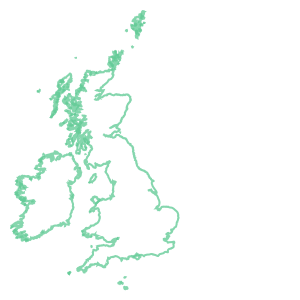

In [64]:
import geopandas as gpd
from shapely.geometry import Point

datasetxx['geometry'] = datasetxx.apply(lambda row: Point(row['Long'], row['Lat']), axis=1)
gdf = gpd.GeoDataFrame(datasetxx, geometry='geometry', crs='EPSG:4326')

coastline = gpd.read_file('data/ukcp18-uk-marine-coastline-lowres.shp')  # or .geojson
coastline.crs = "EPSG:27700"
coastline = coastline.to_crs('EPSG:3857') # Project to metric for distance calculation
gdf = gdf.to_crs('EPSG:3857')

# Create a unary union of the coastline polygons/lines for faster distance computation
coastlines = coastline.boundary
coastline_union = coastlines.unary_union
coastline_geom = gpd.GeoSeries([coastline_union], crs=coastline.crs)

# Compute distance in meters
gdf['distance_to_coast'] = gdf['geometry'].apply(lambda x: x.distance(coastline_geom.iloc[0]))

# 20 km = 20,000 meters
coastal = gdf[gdf['distance_to_coast'] <= 20000]
inland = gdf[gdf['distance_to_coast'] > 20000]

coastal_df = pd.DataFrame(coastal.drop(columns='geometry'))
inland_df = pd.DataFrame(inland.drop(columns='geometry'))
datasetxx = datasetxx.drop(['geometry'], axis=1)
coastline_union

In [65]:
inland_df.shape

(491, 71)

In [66]:
coastal_df.shape

(495, 71)

In [67]:
datasetxx = gdf.drop(['geometry'], axis=1)
datasetxx.shape

(986, 71)

In [70]:
datasetxx = datasetxx.dropna().reset_index(drop=True) # dropping nan satellite data
datasetxx.to_csv('data/val_ecoliall511_weather.csv', index=False)
datasetxx.shape

(965, 71)

Re-order features with respect to the trained model inputs (features)

In [ ]:
table2 = pq.read_table('data/train_ecoliall51_weather.parquet')
datasetxx2 = table2.to_pandas()
datasetxx = datasetxx[datasetxx2.columns]
table = pa.Table.from_pandas(datasetxx)
pq.write_table(table, "data/val_ecoliall511_weather.parquet") # to be shared on GitHub

In [73]:
datasetxx.shape

(965, 71)

## Final Analysis on Generated Data

In [10]:
table2 = pq.read_table('data/val_ecoliall511_weather.parquet')
datasetxx = table2.to_pandas()
datasetxx.shape

(965, 71)

In [11]:
target_date = '2024-07-01'
# Filter the DataFrame to keep only rows on or after the target date
datasetxx = datasetxx[datasetxx['timedate'] >= target_date].reset_index(drop=True)
datasetxx.shape

(649, 71)

In [12]:
datasetxx.columns

Index(['Temp Water', 'Sld Sus@105C', 'Ammonia(N)', 'Nitrate-N', 'Nitrite-N',
       'Lat', 'Long', 'Phosphate', 'lst', 'fpar', 'emis31', 'lai',
       'samplesamplingPoint', 'samplingPointnotation', 'timedate', 'time',
       'date', 'E.coli C-MF', 'temperature_11am', 'humidity_11am',
       'windspeed_11am', 'windgusts_11am', 'winddirection_11am',
       'precipitation_11am', 'rain_11am', 'snowfall_11am', 'cloudcover_11am',
       'pressure_msl_11am', 'soil_temp_7cm', 'soil_moist_7cm', 'vap_press_def',
       'et0_fao_evap', 'sun_duration', 'global_tilted_irr', 'short_rad',
       'dir_rad', 'dew_point_2m', 'temp_min', 'temp_max', 'precipitation_sum',
       'rain_sum', 'snowfall_sum', 'windspeed_max', 'windgusts_max',
       'winddirection_dominant', 'precipitation_hours', 'sunshine_duration_d',
       'daylight_duration_d', 'short_rad_sum_d', 'et0_fao_evap_d', 'temp_min7',
       'temp_max7', 'precipitation_sum7', 'rain_sum7', 'snowfall_sum7',
       'windspeed_max7', 'windgusts_max

<Axes: xlabel='E.coli C-MF', ylabel='None'>

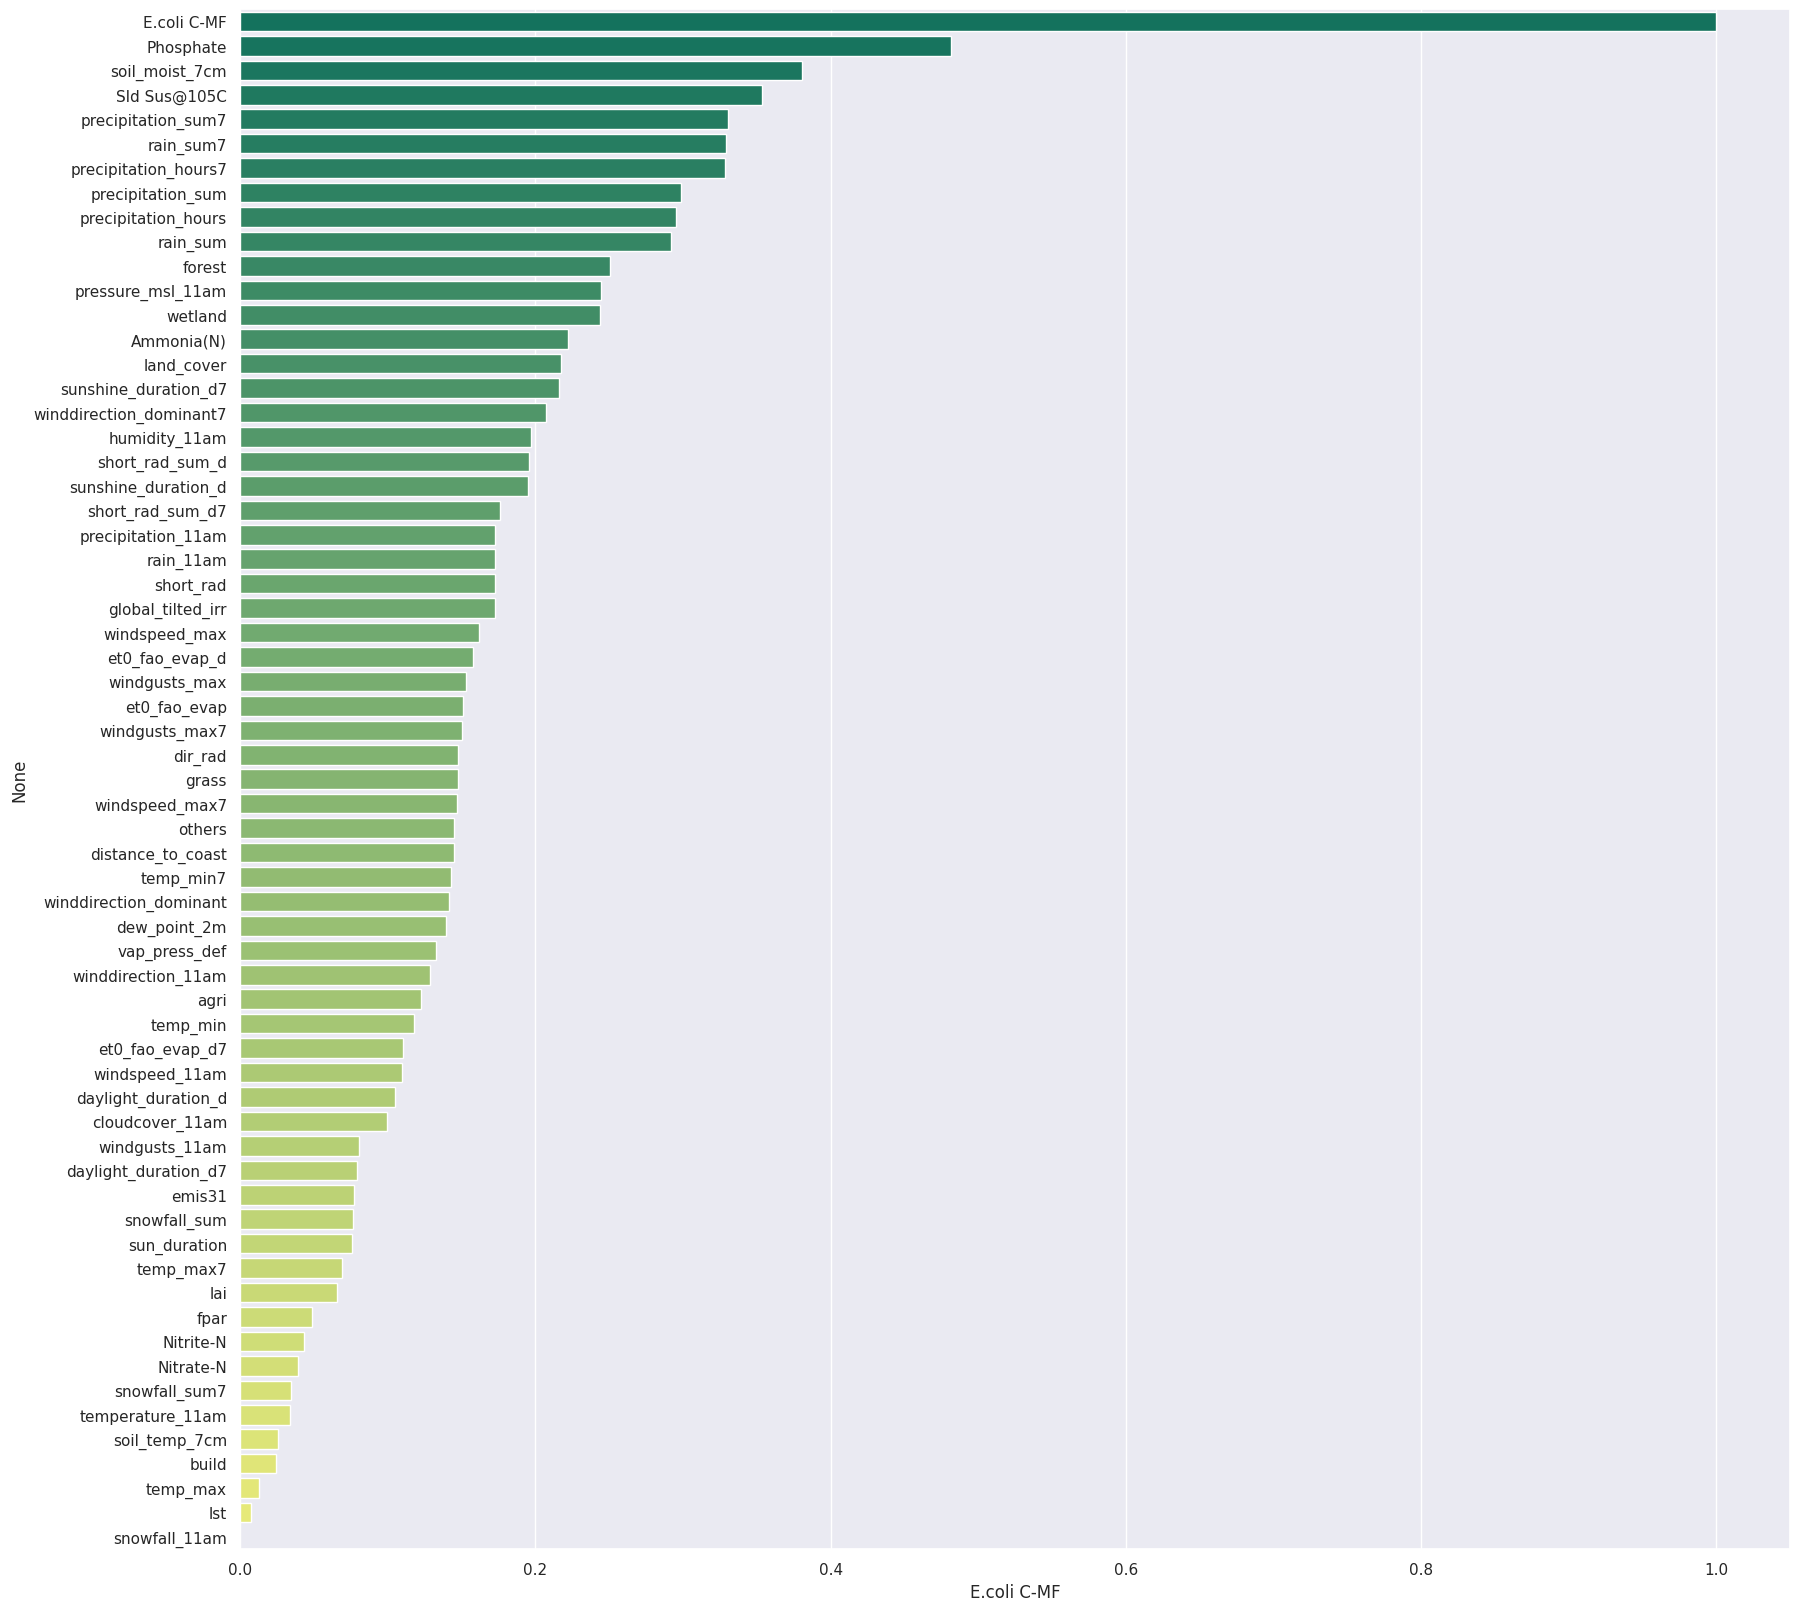

In [13]:
# spearman correlation analysis for E.coli (Sorted)
X = datasetxx.drop(['samplingPointnotation', 'samplesamplingPoint', 
                    'timedate', 'date', 'time', 'Lat', 'Long'],axis=1)
y = datasetxx['E.coli C-MF']

# correlation analysis
corre = X.corr().abs()
temp = X.corr(method='spearman')[["E.coli C-MF"]].iloc[1: , :].abs() #kendall
temp = temp.sort_values('E.coli C-MF',ascending=False)
plt.figure(figsize=(20,20))
sns.barplot(x='E.coli C-MF',y=temp.index,data=temp,orient='h',palette='summer')

<Axes: >

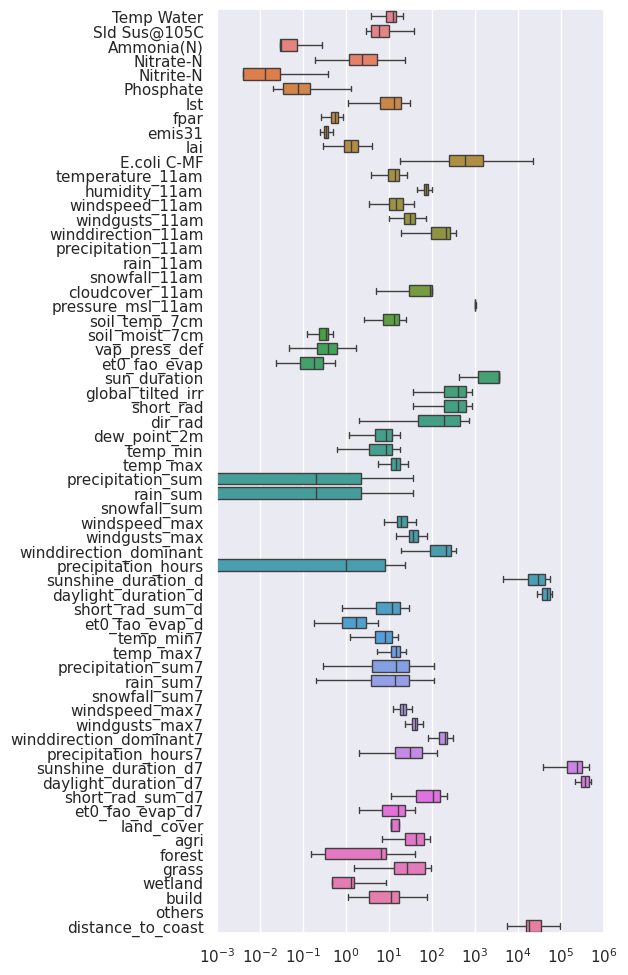

In [14]:
# Features distribution box plot
plt.figure(figsize=(5,12))
plt.xlim(0.001,1000000)
plt.xscale('log')
sns.boxplot(data = datasetxx.drop(['Lat', 'Long','samplesamplingPoint',
                        'samplingPointnotation','timedate', ],axis=1), orient="h", showfliers=False)
